<a href="https://www.kaggle.com/code/lalit7881/strategic-voting-machine-eda?scriptVersionId=320683259" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lukhilaksh/strategic-voting-machine/Vote Ai.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lukhilaksh/strategic-voting-machine/Vote Ai.csv")

In [3]:
df.head()

,Election_ID,State,Constituency_Code,Constituency_Name,Round,Last_Updated_Time,Candidate_Name,Party,Gender,Age,...,Network_Failure_Count,Power_Outage_Risk,Noise_Float_1,Noise_Float_2,Noise_Category,Correlated_Noise_Score,Fraud_Proxy_Duplicate,Election_Result,Fraud_Label,Risk_Category
0,137591d6-2b7b-47af-8ed2-f68e1f5434f6,Bihar,C0008,Nagpur,5,2024-05-21T15:28:18.800054+05:53,Yochana Khurana,YSRCP,Male,57,...,6,0.2407,21.980,31.310,D,0.1434,0.4657,Won,1,High
1,96fb1c8e-c776-4f82-b883-509719f7dadf,Assam,C0317,Sambalpur,1,2024-04-20T02:42:43.430954+05:53,Zansi Tara,NCP,Male,53,...,5,0.0965,94.401,76.622,B,0.3228,0.4280,Won,1,Medium
2,973a3ec0-a2cd-4161-bce9-f9592435f64c,Madhya Pradesh,C0027,Kolhapur,3,2024-05-07T18:43:18.086654+05:53,Falguni Gaba,Independent,Male,63,...,2,0.2881,78.950,70.513,B,0.6605,0.1211,Won,0,Low
3,12135bca-2269-4aa6-b02e-843adfc1eb61,Gujarat,C0276,Bongaigaon,6,2024-05-26T16:25:47.797091+05:53,Radhika Hayer,CPM,Female,66,...,1,0.0592,24.436,55.382,E,0.3970,0.1825,Won,0,Medium
4,12d37e71-d165-49fb-84cf-aea6081da715,Maharashtra,C0472,Gudivada,5,2024-05-21T17:56:21.420097+05:53,Ikbal Venkataraman,JDU,Male,55,...,1,0.1000,70.571,35.088,E,0.0237,0.1079,Lost,0,Low


In [4]:
df.tail()

,Election_ID,State,Constituency_Code,Constituency_Name,Round,Last_Updated_Time,Candidate_Name,Party,Gender,Age,...,Network_Failure_Count,Power_Outage_Risk,Noise_Float_1,Noise_Float_2,Noise_Category,Correlated_Noise_Score,Fraud_Proxy_Duplicate,Election_Result,Fraud_Label,Risk_Category
21995,eefe5bbe-0e04-4675-8788-64b0b64fa117,Tamil Nadu,C0378,Bidhannagar,4,2024-05-14T17:12:54.190794+05:53,Nirja Raghavan,Independent,Male,61,...,3,0.3837,NaN,62.679,D,0.3575,0.3101,Won,0,Medium
21996,1e05d924-05bb-4b23-ad58-2dbba6876cbb,Andhra Pradesh,C0391,Delhi,3,2024-05-08T09:20:04.988438+05:53,Vedika Arya,YSRCP,Male,44,...,2,0.1064,67.476,48.607,C,0.0783,0.0834,Won,1,Medium
21997,8cf59268-f02a-428e-b70b-d40710afa784,Madhya Pradesh,C0076,Medininagar,1,2024-04-20T07:55:03.495834+05:53,Agastya Oak,SP,Male,40,...,0,0.2325,3.785,43.545,A,0.0494,0.0802,Won,0,Low
21998,14de97fe-0aaa-478d-aaa0-d1576e4a3da9,Odisha,C0455,Rohtak,4,2024-05-13T12:49:02.284475+05:53,Gabriel Vora,CPM,Female,63,...,3,0.1513,21.774,69.182,D,0.0657,0.1458,Won,0,Low
21999,892b9e9a-36d1-42cd-a888-834cf7be79b6,Bihar,C0345,Thane,4,2024-05-14T16:07:20.661773+05:53,Nidra Vasa,BSP,Male,49,...,0,0.2995,51.007,67.284,B,0.0152,0.2056,Lost,0,Medium


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Election_ID                   22000 non-null  object 
 1   State                         22000 non-null  object 
 2   Constituency_Code             22000 non-null  object 
 3   Constituency_Name             22000 non-null  object 
 4   Round                         22000 non-null  int64  
 5   Last_Updated_Time             22000 non-null  object 
 6   Candidate_Name                22000 non-null  object 
 7   Party                         22000 non-null  object 
 8   Gender                        22000 non-null  object 
 9   Age                           22000 non-null  int64  
 10  Education                     22000 non-null  object 
 11  Criminal_Cases                22000 non-null  int64  
 12  Assets_Cr                     21337 non-null  float64
 13  L

In [6]:
df.describe()

,Round,Age,Criminal_Cases,Assets_Cr,Liabilities_Cr,Campaign_Spending_Cr,Social_Media_Followers,Speech_Sentiment,Popularity_Score,Historical_Win_Rate,...,Time_Between_Updates_min,Sequential_Risk_Score,Server_Delay_ms,Network_Failure_Count,Power_Outage_Risk,Noise_Float_1,Noise_Float_2,Correlated_Noise_Score,Fraud_Proxy_Duplicate,Fraud_Label
count,22000.000000,22000.000000,22000.000000,21337.000000,21319.000000,20672.000000,2.200000e+04,21129.000000,22000.000000,22000.000000,...,21537.000000,22000.000000,21110.000000,22000.000000,22000.00000,20843.000000,20894.000000,22000.000000,22000.000000,22000.000000
mean,3.689955,51.573545,1.875909,5.040252,1.434810,1.131158,5.095403e+04,0.515570,0.561238,0.418132,...,58.615244,0.233350,289.136532,2.046773,0.20596,50.190101,50.004835,0.326545,0.276242,0.316818
std,1.979671,9.939530,2.610504,9.280800,2.931141,2.379402,1.389684e+05,0.193398,0.104015,0.166254,...,45.422702,0.120186,167.721569,1.585809,0.11776,28.831891,15.102088,0.237584,0.113033,0.465246
min,1.000000,25.000000,0.000000,0.030000,0.000000,0.000000,1.000000e+02,0.022800,0.178900,0.000000,...,5.000000,0.001900,25.800000,0.000000,0.02040,0.001000,-12.890000,0.000000,0.000000,0.000000
25%,2.000000,45.000000,0.000000,1.080000,0.230000,0.200000,5.844250e+03,0.370000,0.492000,0.298800,...,27.000000,0.136000,187.400000,1.000000,0.11610,25.128500,39.892500,0.130150,0.197700,0.000000
50%,4.000000,52.000000,1.000000,2.450000,0.580000,0.480000,1.608100e+04,0.517300,0.563650,0.413550,...,45.900000,0.217250,256.500000,2.000000,0.17900,50.372000,50.051000,0.310650,0.274650,0.000000
75%,5.000000,58.000000,3.000000,5.500000,1.470000,1.180000,4.513775e+04,0.662200,0.633425,0.535325,...,77.100000,0.301900,349.200000,3.000000,0.26980,75.257500,60.128750,0.487300,0.353500,1.000000
max,7.000000,82.000000,29.000000,382.710000,80.310000,102.690000,5.697648e+06,0.991900,0.931200,1.000000,...,429.200000,0.734400,3634.000000,12.000000,0.90990,99.991000,109.849000,1.000000,0.709800,1.000000


In [7]:
df.isnull().sum()

Election_ID               0
State                     0
Constituency_Code         0
Constituency_Name         0
Round                     0
                         ..
Correlated_Noise_Score    0
Fraud_Proxy_Duplicate     0
Election_Result           0
Fraud_Label               0
Risk_Category             0
Length: 62, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Election_ID                object
State                      object
Constituency_Code          object
Constituency_Name          object
Round                       int64
                           ...   
Correlated_Noise_Score    float64
Fraud_Proxy_Duplicate     float64
Election_Result            object
Fraud_Label                 int64
Risk_Category              object
Length: 62, dtype: object

In [10]:
df.shape

(22000, 62)

In [11]:
df.columns

Index(['Election_ID', 'State', 'Constituency_Code', 'Constituency_Name',
       'Round', 'Last_Updated_Time', 'Candidate_Name', 'Party', 'Gender',
       'Age', 'Education', 'Criminal_Cases', 'Assets_Cr', 'Liabilities_Cr',
       'Campaign_Spending_Cr', 'Social_Media_Followers', 'Speech_Sentiment',
       'Popularity_Score', 'Historical_Win_Rate', 'Registered_Voters',
       'EVM_Votes', 'Postal_Votes', 'Total_Votes', 'Vote_Percentage',
       'Vote_Surge_Score', 'Constituency_Volatility',
       'Independent_Candidate_Count', 'Voter_Turnout', 'Urban_Voter_Ratio',
       'Rural_Voter_Ratio', 'Postal_Vote_Ratio', 'Fraud_Risk_Score',
       'Anomaly_Score', 'Strategic_Manipulation_Score', 'Bot_Activity_Flag',
       'Fake_News_Score', 'Cyber_Attack_Risk', 'Booth_Capture_Risk',
       'Deepfake_Propagation_Score', 'Suspicious_Timing_Index',
       'Vote_Injection_Risk', 'Attack_Type', 'Defense_Strategy',
       'Adversarial_Pressure', 'Strategic_Polarization_Index',
       'Influence_Netw

In [12]:
df.nunique()

Election_ID               22000
State                        20
Constituency_Code           542
Constituency_Name           316
Round                         7
                          ...  
Correlated_Noise_Score     7408
Fraud_Proxy_Duplicate      4920
Election_Result               2
Fraud_Label                   2
Risk_Category                 4
Length: 62, dtype: int64

## EDA

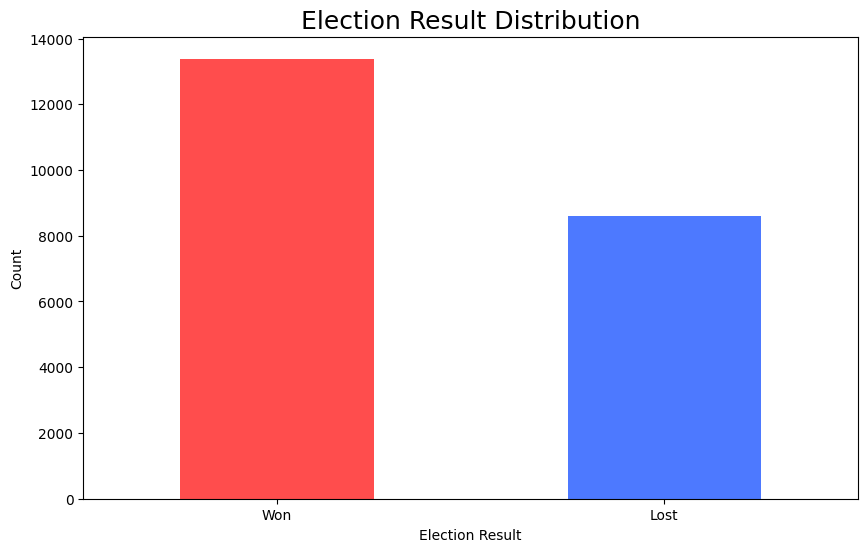

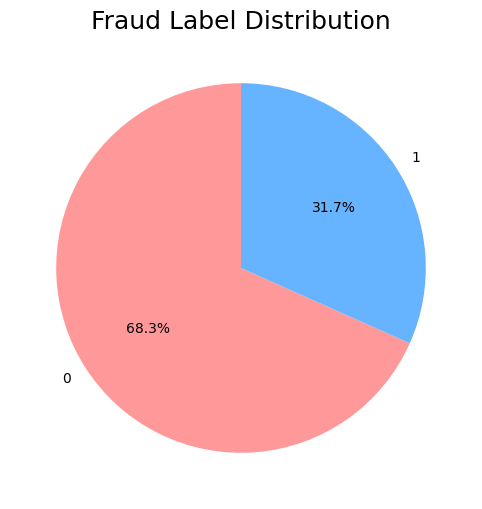

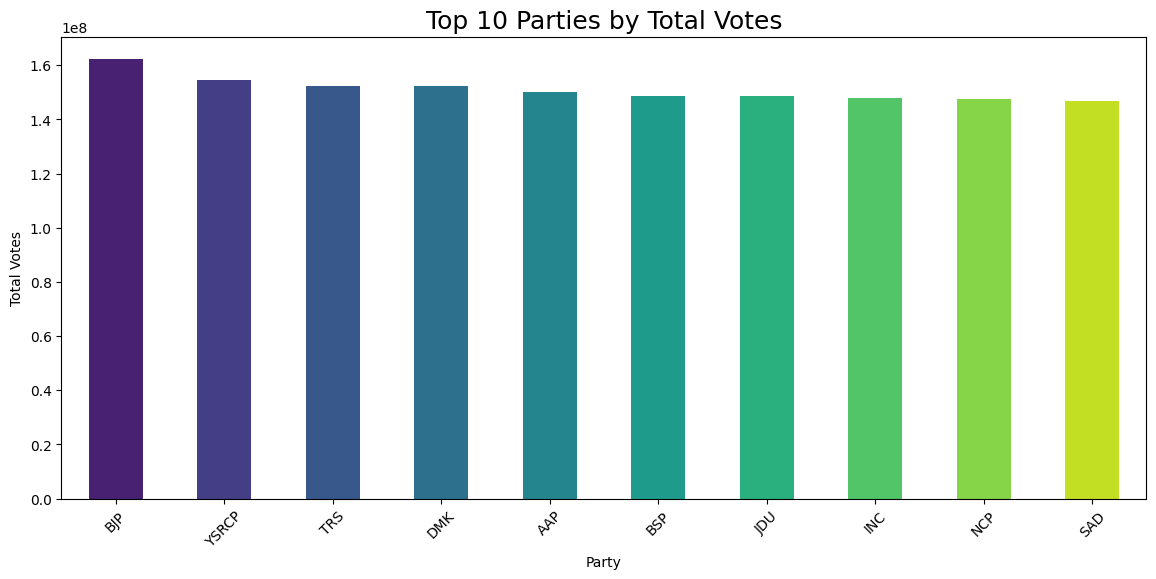

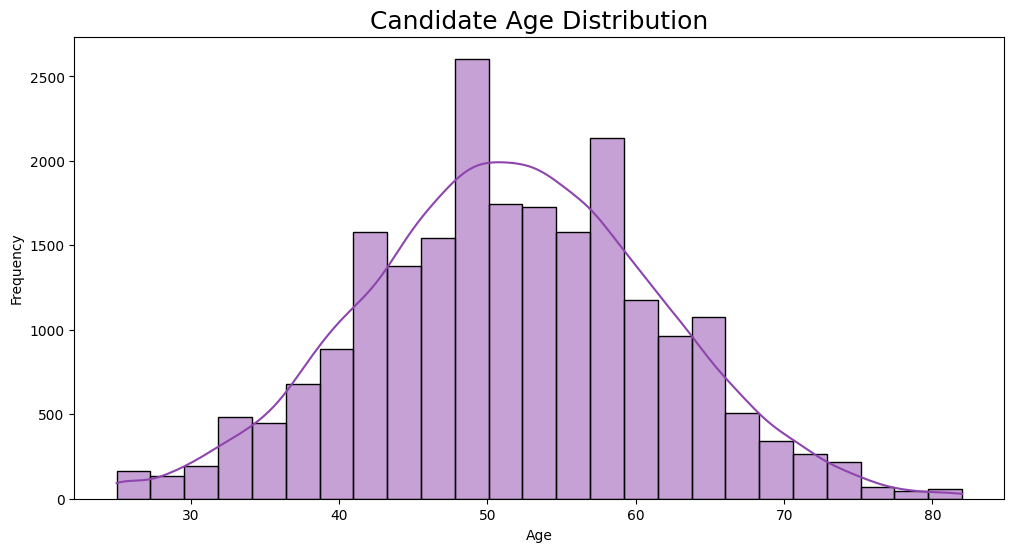

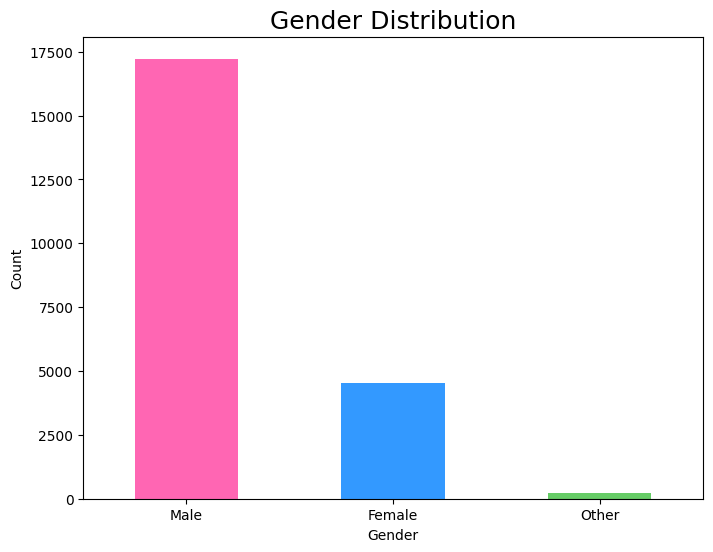

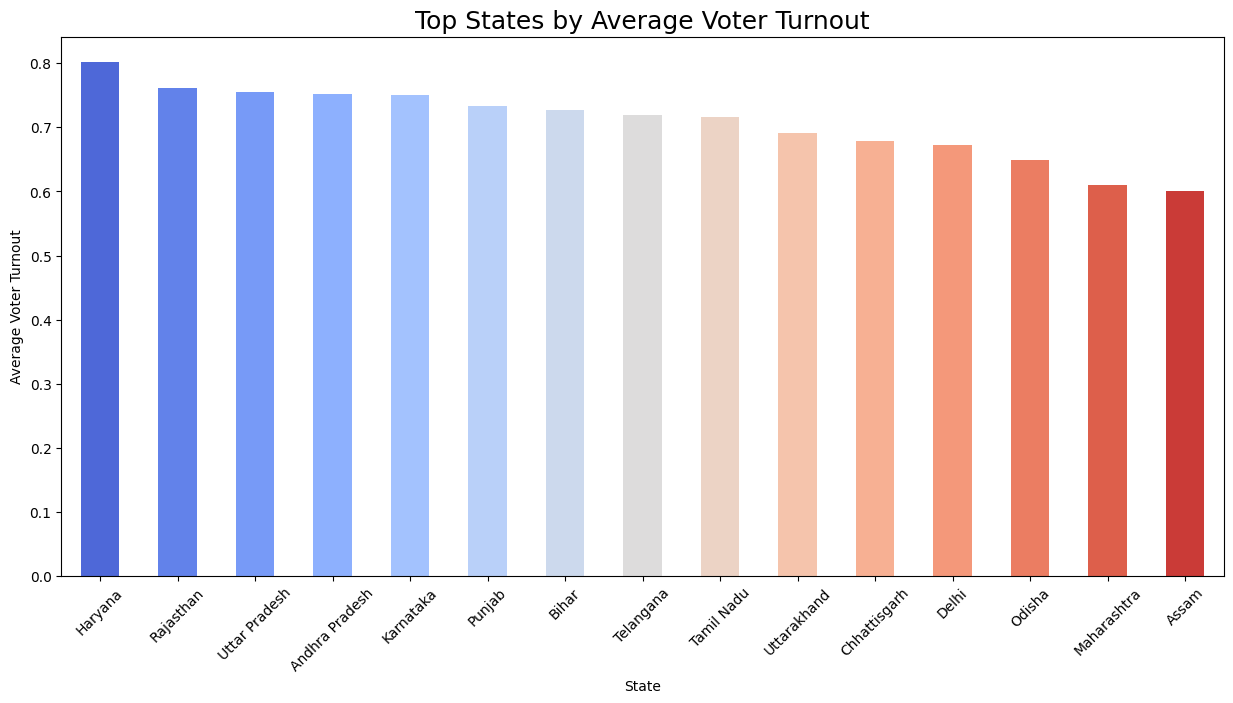

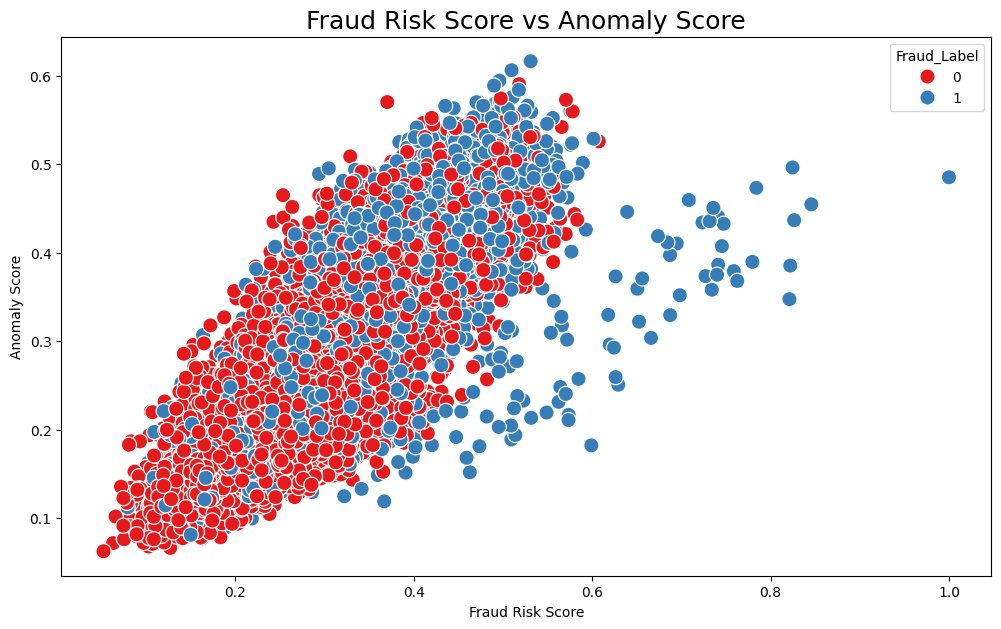

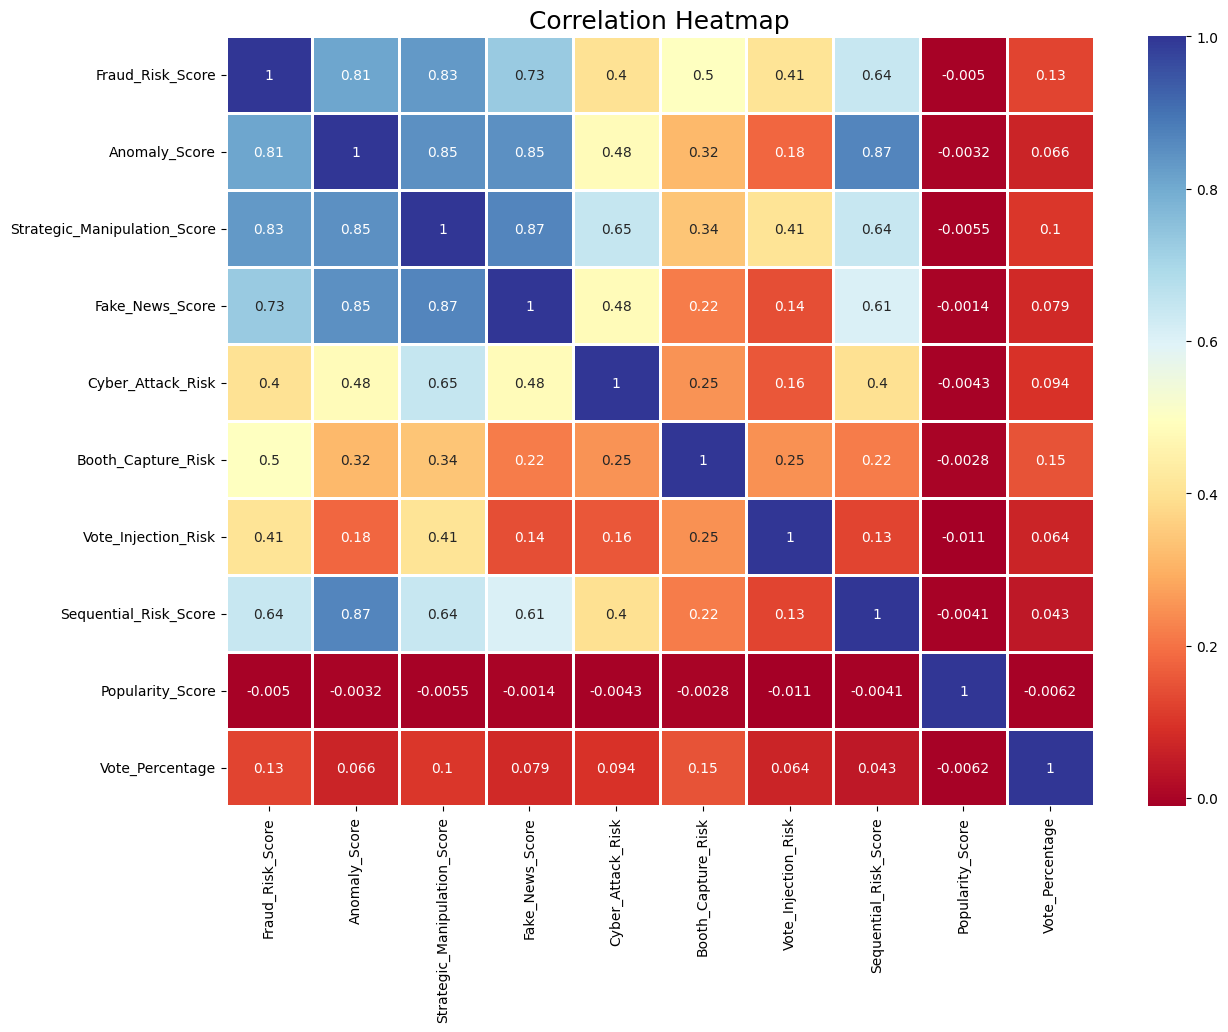

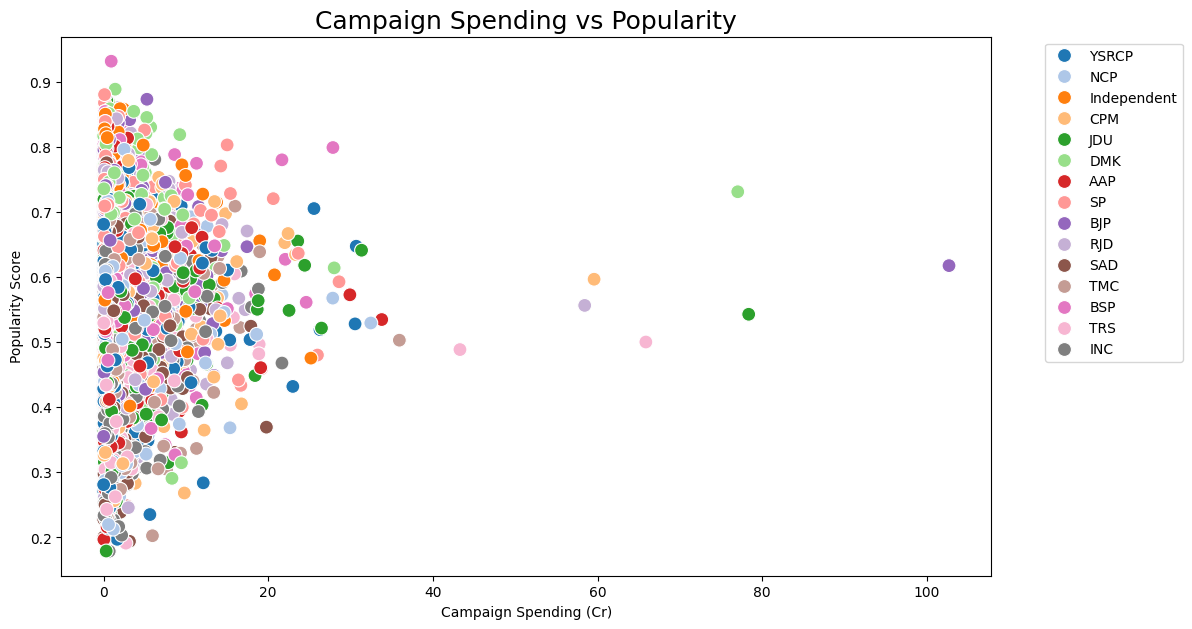

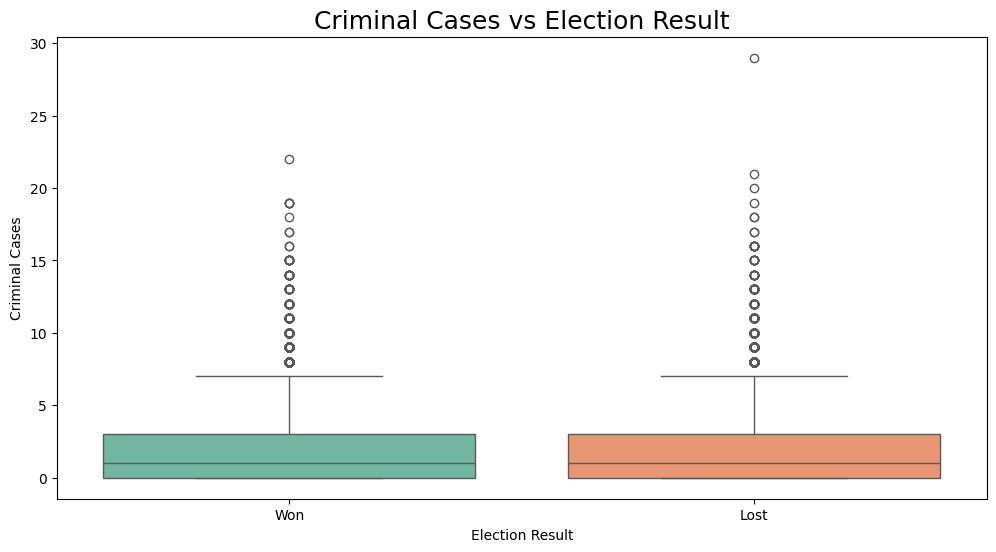

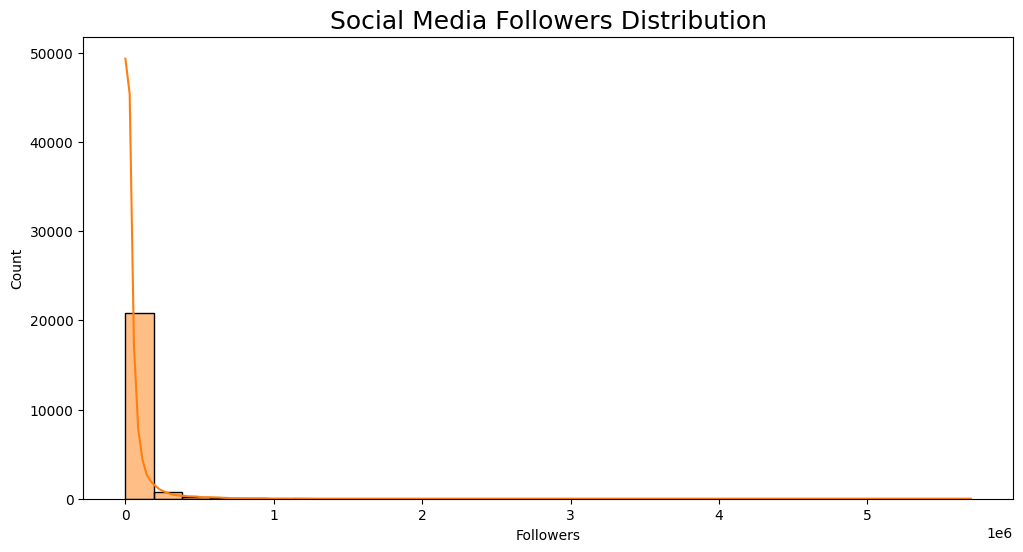

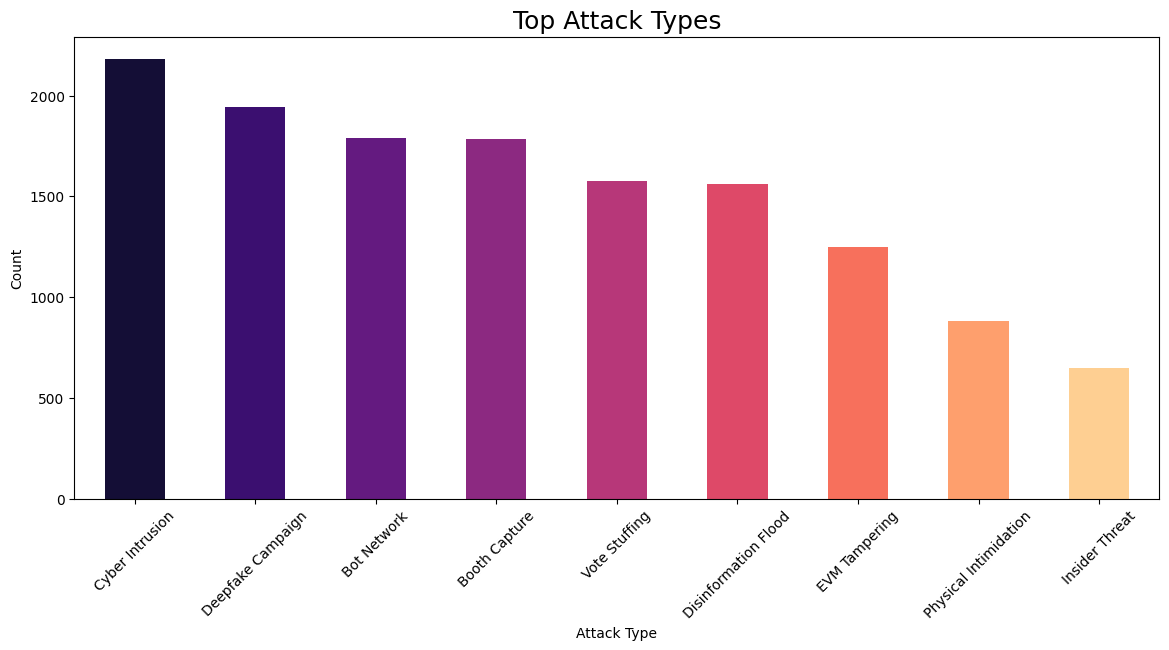

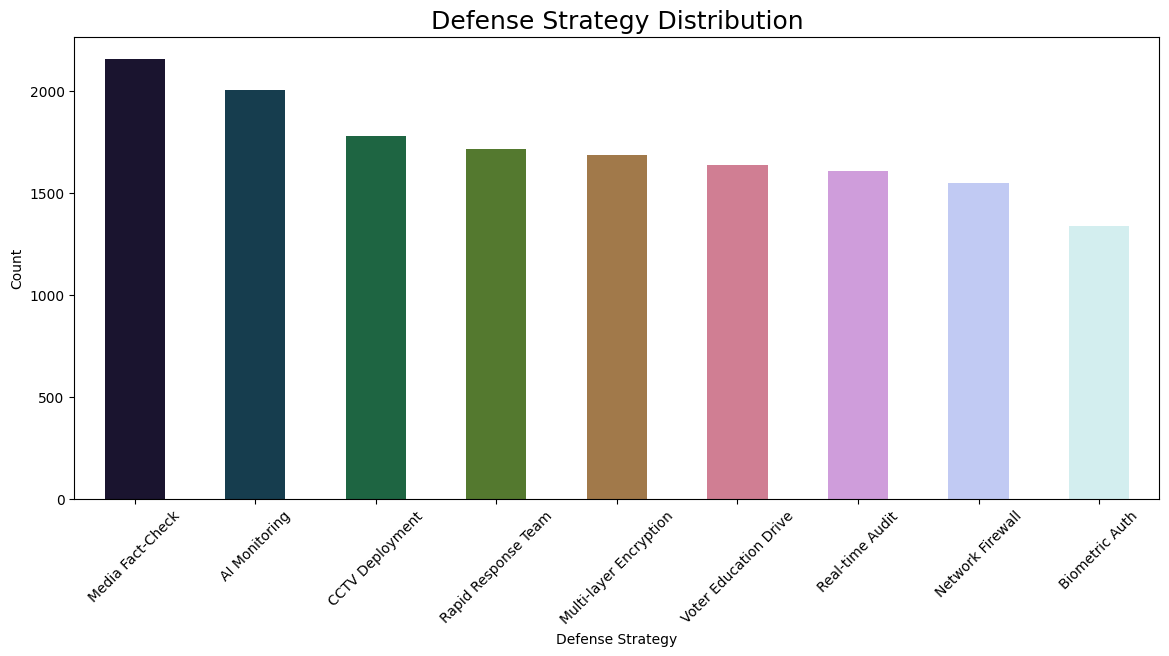

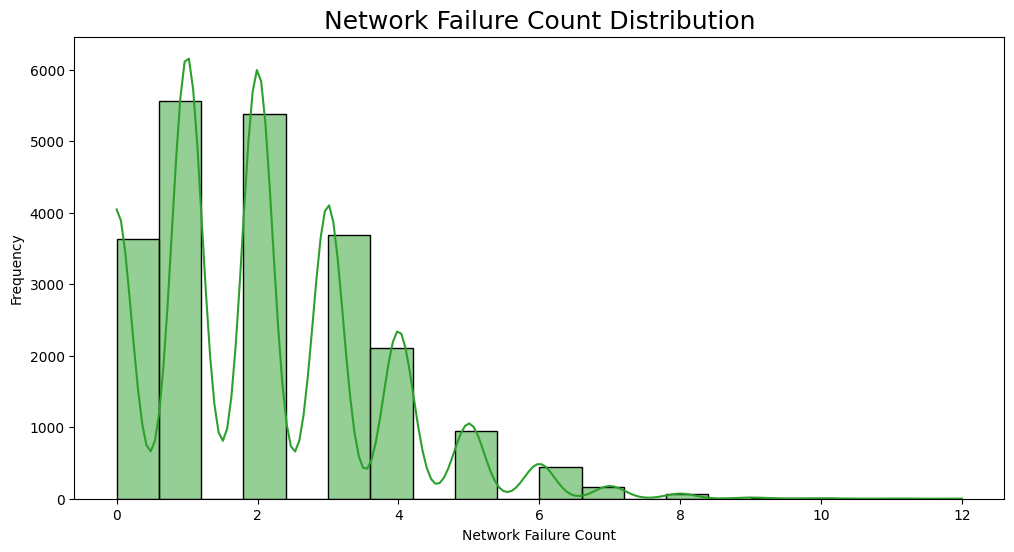

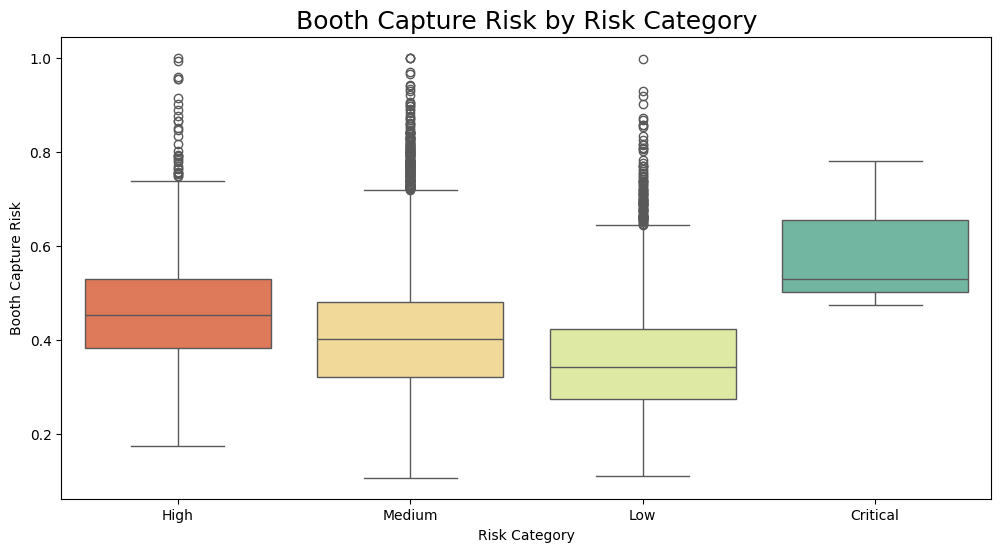

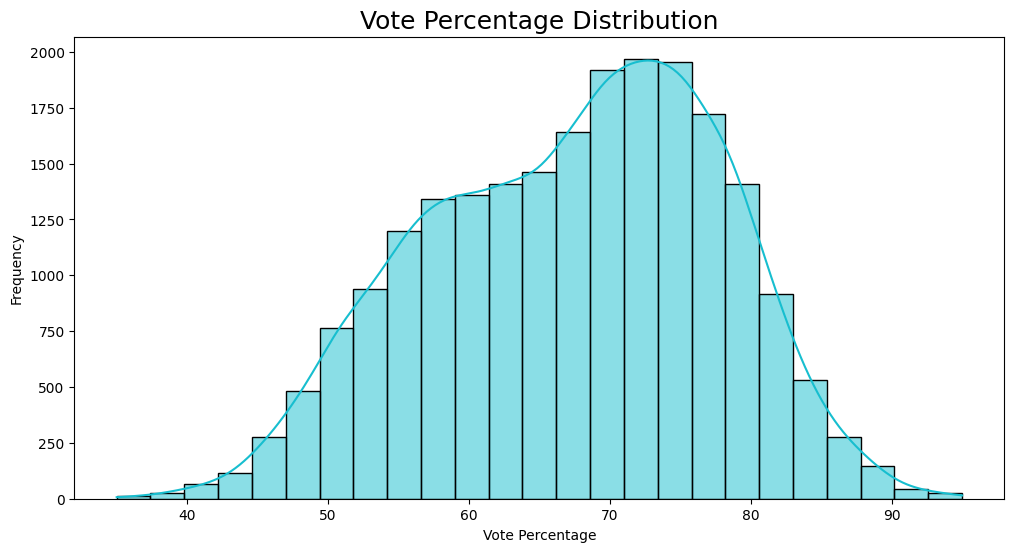

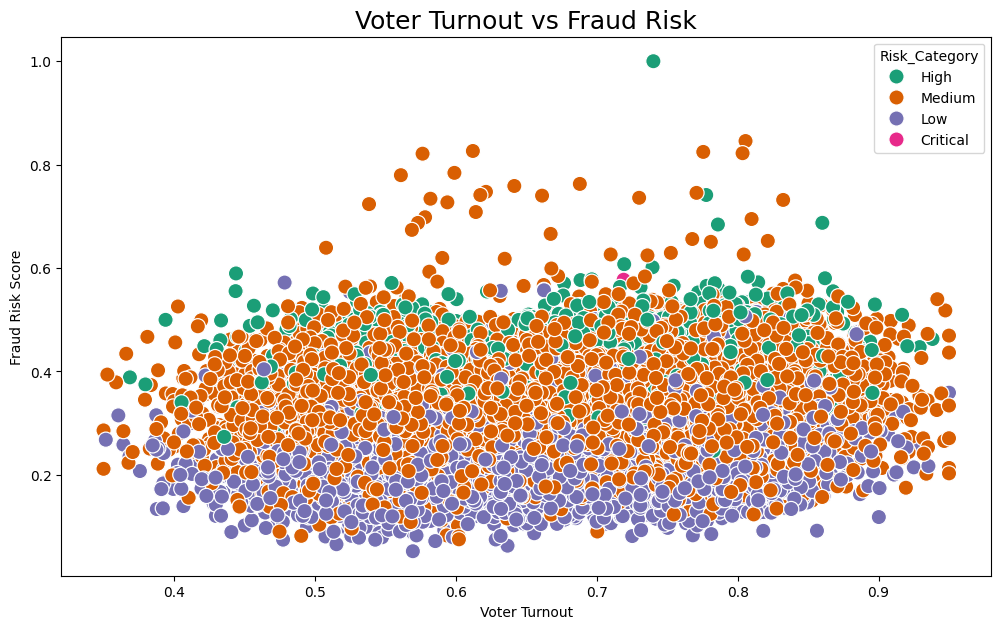

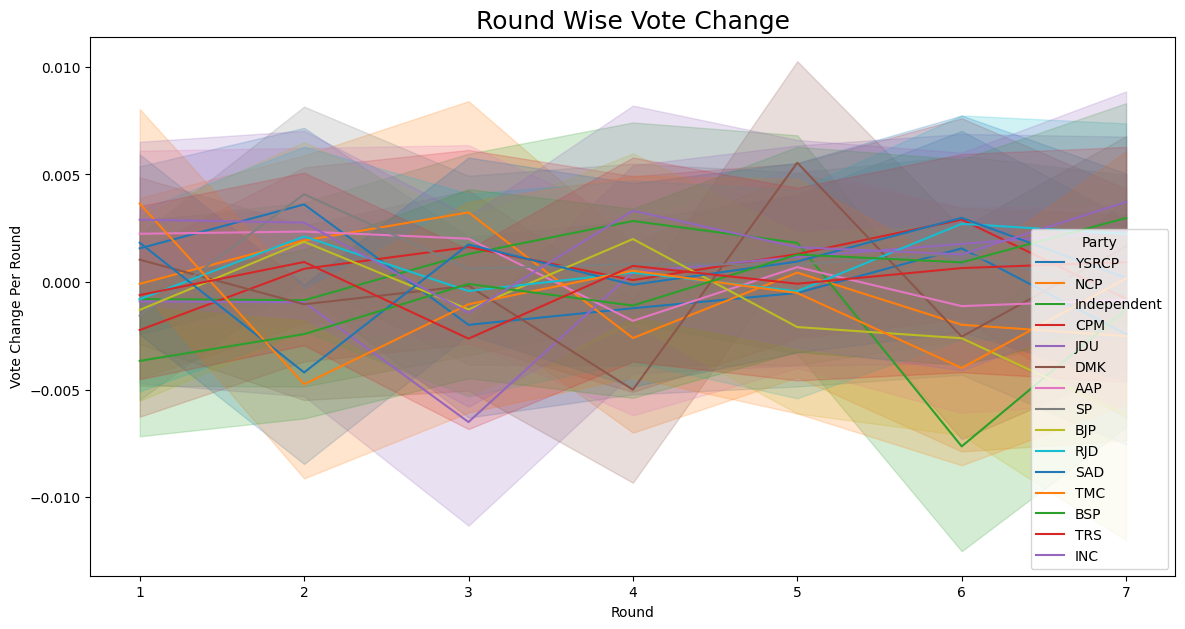

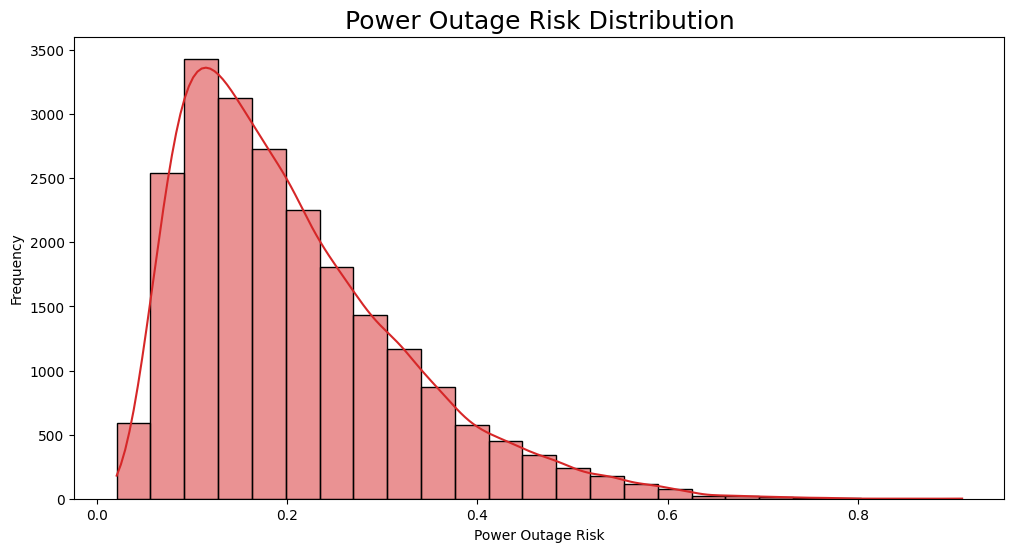

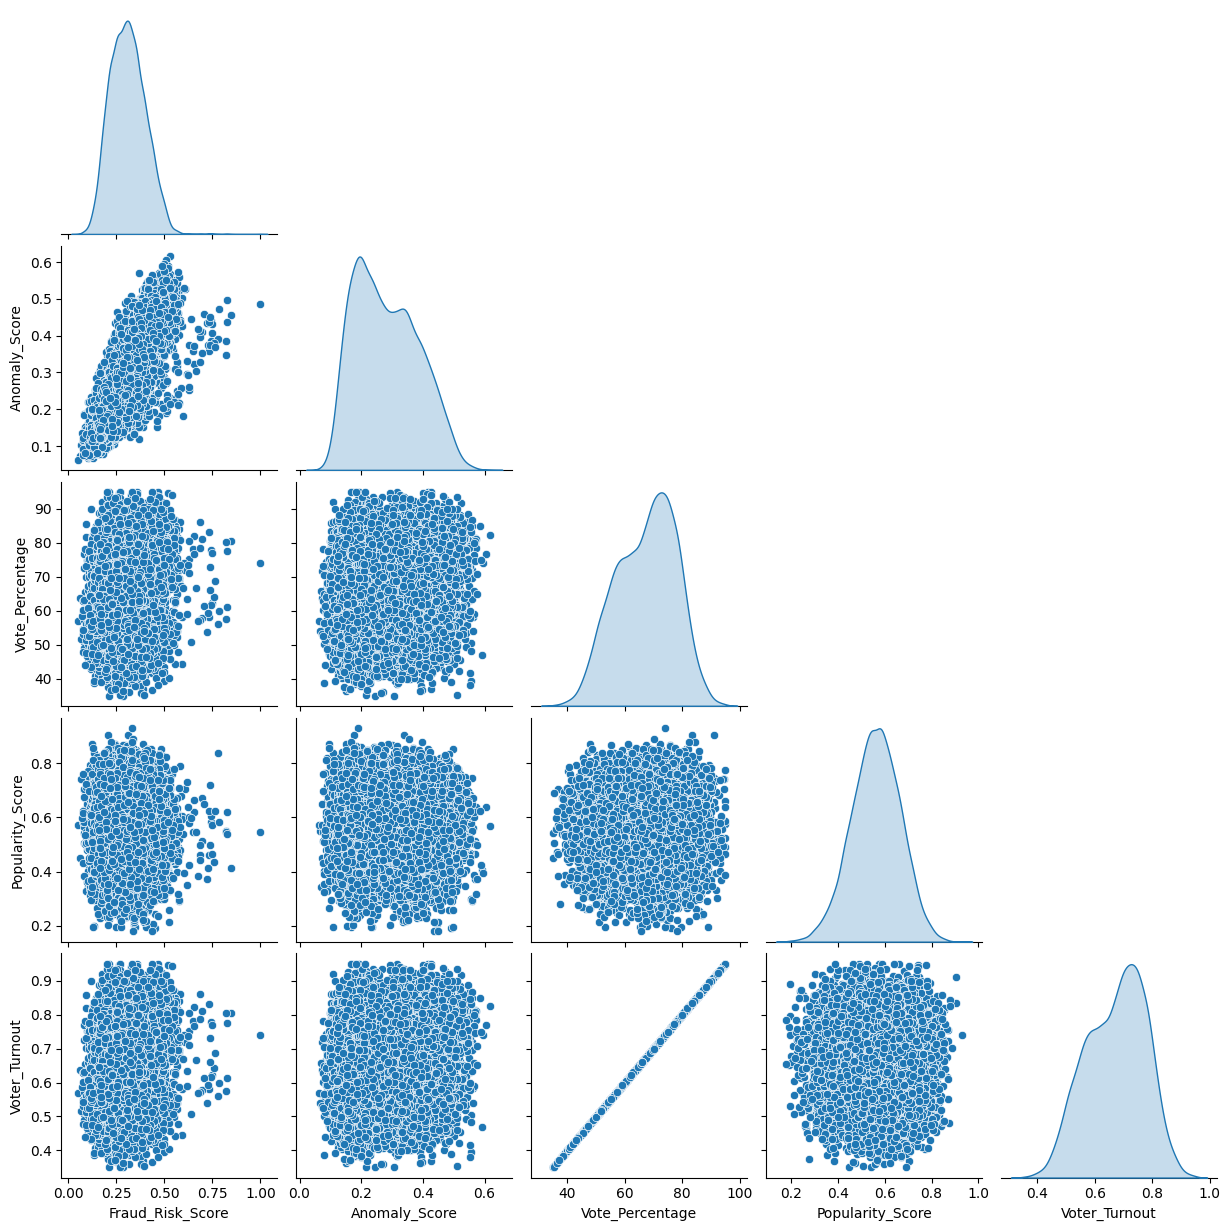

In [13]:
# ============================================================
# 1. ELECTION RESULT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

colors = ["#ff4d4d", "#4d79ff", "#33cc33", "#ffcc00"]

df['Election_Result'].value_counts().plot(
    kind='bar',
    color=colors
)

plt.title("Election Result Distribution", fontsize=18)
plt.xlabel("Election Result")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# ============================================================
# 2. FRAUD LABEL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,6))

fraud_colors = ["#ff9999", "#66b3ff"]

df['Fraud_Label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=fraud_colors,
    startangle=90
)

plt.title("Fraud Label Distribution", fontsize=18)
plt.ylabel("")
plt.show()

# ============================================================
# 3. PARTY WISE TOTAL VOTES
# ============================================================

top_parties = df.groupby("Party")["Total_Votes"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14,6))

party_colors = sns.color_palette("viridis", len(top_parties))

top_parties.plot(
    kind='bar',
    color=party_colors
)

plt.title("Top 10 Parties by Total Votes", fontsize=18)
plt.xlabel("Party")
plt.ylabel("Total Votes")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 4. AGE DISTRIBUTION OF CANDIDATES
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Age'],
    bins=25,
    kde=True,
    color="#8e44ad"
)

plt.title("Candidate Age Distribution", fontsize=18)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# ============================================================
# 5. GENDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,6))

gender_colors = ["#ff66b3", "#3399ff", "#66cc66"]

df['Gender'].value_counts().plot(
    kind='bar',
    color=gender_colors
)

plt.title("Gender Distribution", fontsize=18)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# ============================================================
# 6. TOP STATES BY VOTER TURNOUT
# ============================================================

state_turnout = df.groupby("State")["Voter_Turnout"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(15,7))

state_colors = sns.color_palette("coolwarm", len(state_turnout))

state_turnout.plot(
    kind='bar',
    color=state_colors
)

plt.title("Top States by Average Voter Turnout", fontsize=18)
plt.xlabel("State")
plt.ylabel("Average Voter Turnout")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 7. FRAUD RISK SCORE VS ANOMALY SCORE
# ============================================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    x='Fraud_Risk_Score',
    y='Anomaly_Score',
    hue='Fraud_Label',
    palette='Set1',
    data=df,
    s=120
)

plt.title("Fraud Risk Score vs Anomaly Score", fontsize=18)
plt.xlabel("Fraud Risk Score")
plt.ylabel("Anomaly Score")
plt.show()

# ============================================================
# 8. HEATMAP OF IMPORTANT NUMERICAL FEATURES
# ============================================================

important_cols = [
    'Fraud_Risk_Score',
    'Anomaly_Score',
    'Strategic_Manipulation_Score',
    'Fake_News_Score',
    'Cyber_Attack_Risk',
    'Booth_Capture_Risk',
    'Vote_Injection_Risk',
    'Sequential_Risk_Score',
    'Popularity_Score',
    'Vote_Percentage'
]

corr = df[important_cols].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlBu',
    linewidths=1
)

plt.title("Correlation Heatmap", fontsize=18)
plt.show()

# ============================================================
# 9. CAMPAIGN SPENDING VS POPULARITY
# ============================================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    x='Campaign_Spending_Cr',
    y='Popularity_Score',
    hue='Party',
    palette='tab20',
    data=df,
    s=100
)

plt.title("Campaign Spending vs Popularity", fontsize=18)
plt.xlabel("Campaign Spending (Cr)")
plt.ylabel("Popularity Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# ============================================================
# 10. CRIMINAL CASES DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Election_Result',
    y='Criminal_Cases',
    palette='Set2',
    data=df
)

plt.title("Criminal Cases vs Election Result", fontsize=18)
plt.xlabel("Election Result")
plt.ylabel("Criminal Cases")
plt.show()

# ============================================================
# 11. SOCIAL MEDIA FOLLOWERS DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Social_Media_Followers'],
    bins=30,
    color="#ff7f0e",
    kde=True
)

plt.title("Social Media Followers Distribution", fontsize=18)
plt.xlabel("Followers")
plt.ylabel("Count")
plt.show()

# ============================================================
# 12. ATTACK TYPE ANALYSIS
# ============================================================

plt.figure(figsize=(14,6))

attack_counts = df['Attack_Type'].value_counts().head(10)

attack_colors = sns.color_palette("magma", len(attack_counts))

attack_counts.plot(
    kind='bar',
    color=attack_colors
)

plt.title("Top Attack Types", fontsize=18)
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 13. DEFENSE STRATEGY ANALYSIS
# ============================================================

plt.figure(figsize=(14,6))

defense_counts = df['Defense_Strategy'].value_counts().head(10)

defense_colors = sns.color_palette("cubehelix", len(defense_counts))

defense_counts.plot(
    kind='bar',
    color=defense_colors
)

plt.title("Defense Strategy Distribution", fontsize=18)
plt.xlabel("Defense Strategy")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 14. NETWORK FAILURE COUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Network_Failure_Count'],
    bins=20,
    color="#2ca02c",
    kde=True
)

plt.title("Network Failure Count Distribution", fontsize=18)
plt.xlabel("Network Failure Count")
plt.ylabel("Frequency")
plt.show()

# ============================================================
# 15. BOOTH CAPTURE RISK ANALYSIS
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Risk_Category',
    y='Booth_Capture_Risk',
    palette='Spectral',
    data=df
)

plt.title("Booth Capture Risk by Risk Category", fontsize=18)
plt.xlabel("Risk Category")
plt.ylabel("Booth Capture Risk")
plt.show()

# ============================================================
# 16. VOTE PERCENTAGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Vote_Percentage'],
    bins=25,
    color="#17becf",
    kde=True
)

plt.title("Vote Percentage Distribution", fontsize=18)
plt.xlabel("Vote Percentage")
plt.ylabel("Frequency")
plt.show()

# ============================================================
# 17. VOTER TURNOUT VS FRAUD RISK
# ============================================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    x='Voter_Turnout',
    y='Fraud_Risk_Score',
    hue='Risk_Category',
    palette='Dark2',
    data=df,
    s=120
)

plt.title("Voter Turnout vs Fraud Risk", fontsize=18)
plt.xlabel("Voter Turnout")
plt.ylabel("Fraud Risk Score")
plt.show()

# ============================================================
# 18. TIME SERIES OF ROUND WISE VOTE CHANGE
# ============================================================

plt.figure(figsize=(14,7))

sns.lineplot(
    x='Round',
    y='Vote_Change_Per_Round',
    hue='Party',
    palette='tab10',
    data=df
)

plt.title("Round Wise Vote Change", fontsize=18)
plt.xlabel("Round")
plt.ylabel("Vote Change Per Round")
plt.show()

# ============================================================
# 19. POWER OUTAGE RISK DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Power_Outage_Risk'],
    bins=25,
    color="#d62728",
    kde=True
)

plt.title("Power Outage Risk Distribution", fontsize=18)
plt.xlabel("Power Outage Risk")
plt.ylabel("Frequency")
plt.show()

# ============================================================
# 20. PAIRPLOT OF IMPORTANT FEATURES
# ============================================================

pairplot_cols = [
    'Fraud_Risk_Score',
    'Anomaly_Score',
    'Vote_Percentage',
    'Popularity_Score',
    'Voter_Turnout'
]

sns.pairplot(
    df[pairplot_cols],
    corner=True,
    diag_kind='kde'
)

plt.show()

## Feature engineering


Target Classes:
[0 1]

Categorical Columns:
['Election_ID', 'State', 'Constituency_Code', 'Constituency_Name', 'Last_Updated_Time', 'Candidate_Name', 'Party', 'Gender', 'Education', 'Attack_Type', 'Defense_Strategy', 'EVM_Device_ID', 'Noise_Category']

Numerical Columns:
['Round', 'Age', 'Criminal_Cases', 'Assets_Cr', 'Liabilities_Cr', 'Campaign_Spending_Cr', 'Social_Media_Followers', 'Speech_Sentiment', 'Popularity_Score', 'Historical_Win_Rate', 'Registered_Voters', 'EVM_Votes', 'Postal_Votes', 'Total_Votes', 'Vote_Percentage', 'Vote_Surge_Score', 'Constituency_Volatility', 'Independent_Candidate_Count', 'Voter_Turnout', 'Urban_Voter_Ratio', 'Rural_Voter_Ratio', 'Postal_Vote_Ratio', 'Fraud_Risk_Score', 'Anomaly_Score', 'Strategic_Manipulation_Score', 'Bot_Activity_Flag', 'Fake_News_Score', 'Cyber_Attack_Risk', 'Booth_Capture_Risk', 'Deepfake_Propagation_Score', 'Suspicious_Timing_Index', 'Vote_Injection_Risk', 'Adversarial_Pressure', 'Strategic_Polarization_Index', 'Influence_Network

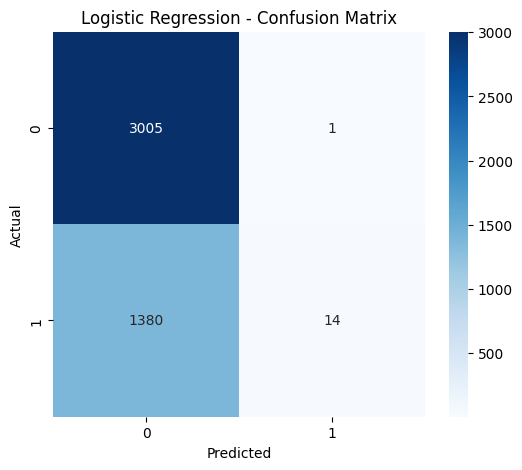

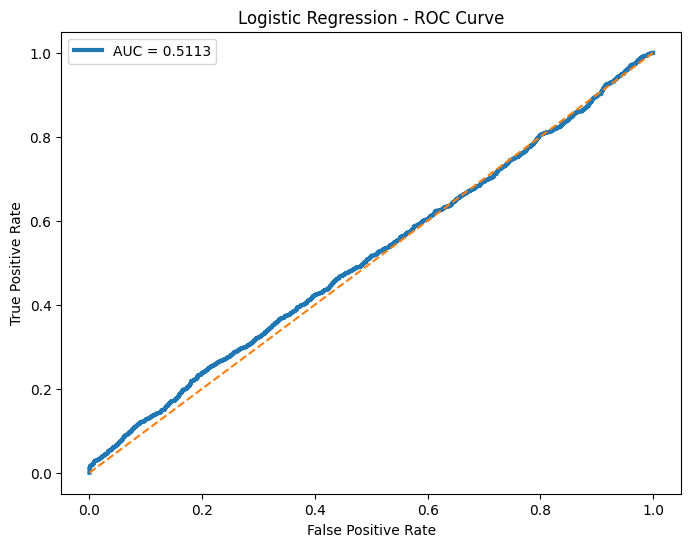



Decision Tree

Accuracy Score: 0.6684
ROC AUC Score: 0.6112

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.86      0.78      3006
           1       0.46      0.26      0.33      1394

    accuracy                           0.67      4400
   macro avg       0.59      0.56      0.56      4400
weighted avg       0.63      0.67      0.64      4400



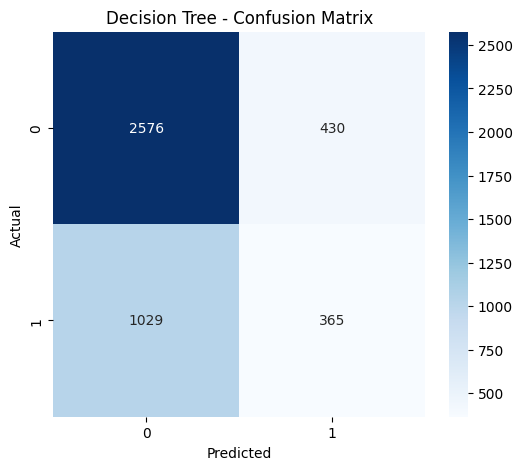

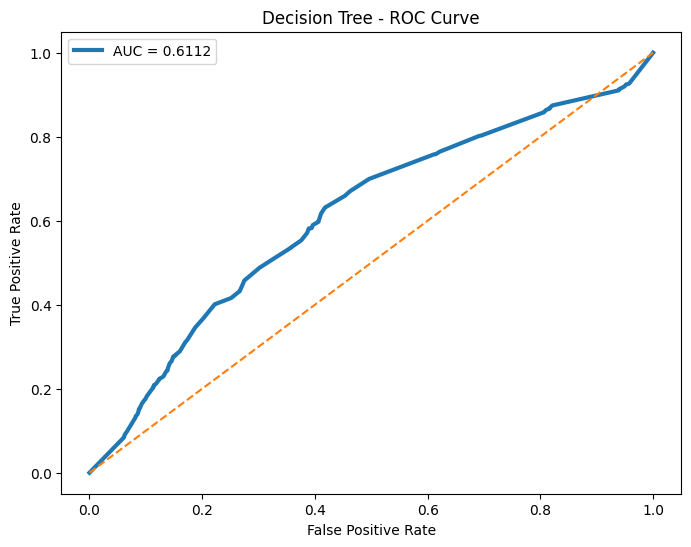



Random Forest

Accuracy Score: 0.7032
ROC AUC Score: 0.6893

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.88      0.80      3006
           1       0.55      0.33      0.41      1394

    accuracy                           0.70      4400
   macro avg       0.65      0.60      0.61      4400
weighted avg       0.68      0.70      0.68      4400



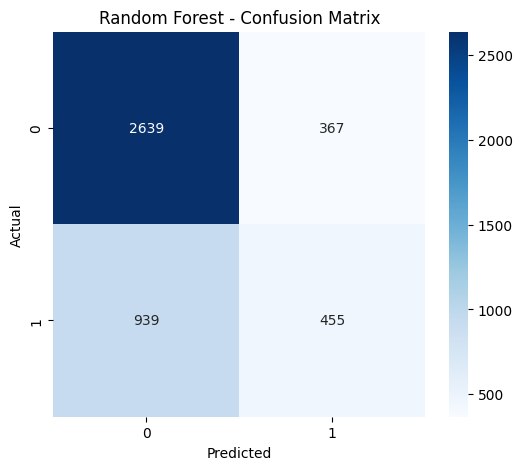

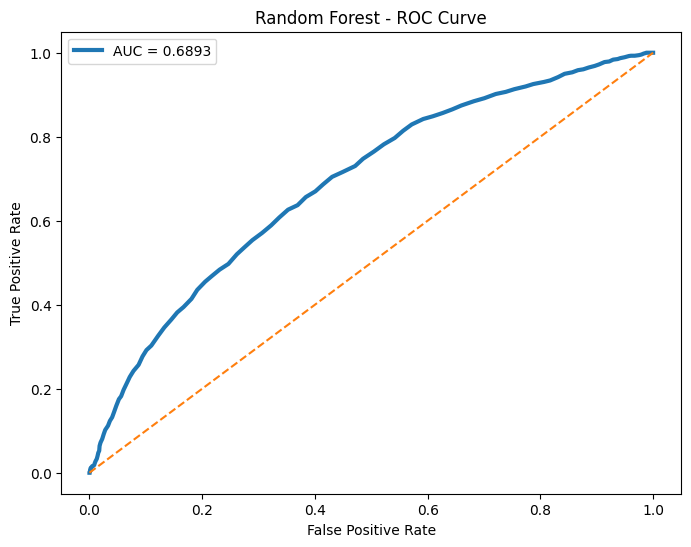



Gradient Boosting

Accuracy Score: 0.6880
ROC AUC Score: 0.6924

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.80      0.78      3006
           1       0.51      0.45      0.48      1394

    accuracy                           0.69      4400
   macro avg       0.63      0.62      0.63      4400
weighted avg       0.68      0.69      0.68      4400



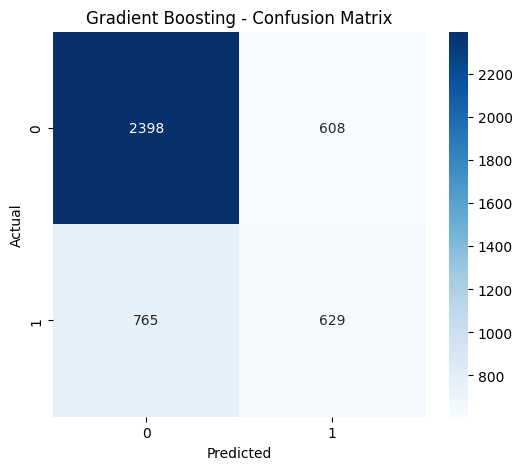

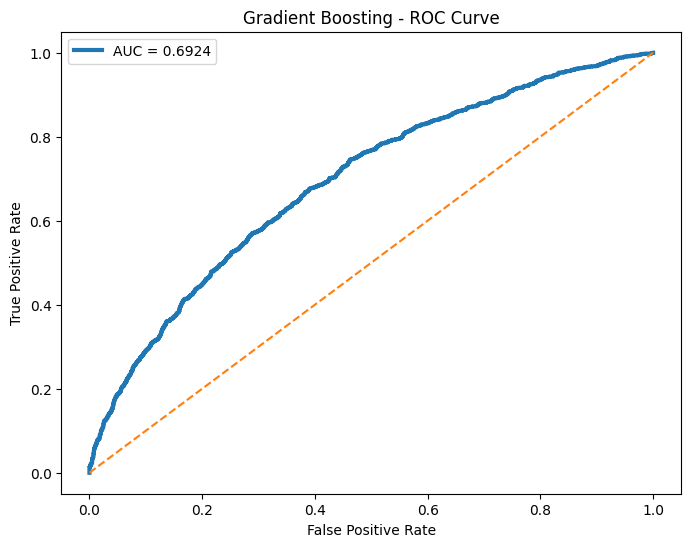



Extra Trees

Accuracy Score: 0.7030
ROC AUC Score: 0.6913

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.90      0.81      3006
           1       0.57      0.27      0.36      1394

    accuracy                           0.70      4400
   macro avg       0.65      0.59      0.59      4400
weighted avg       0.68      0.70      0.67      4400



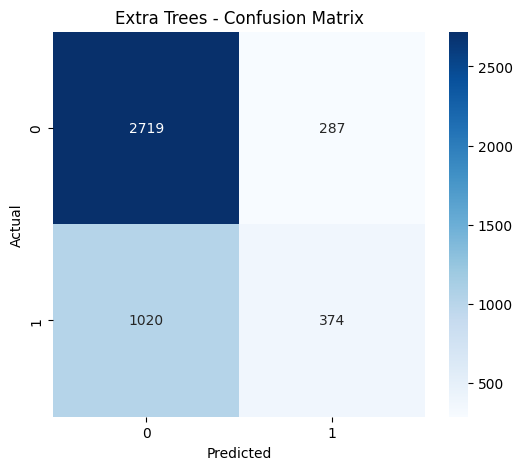

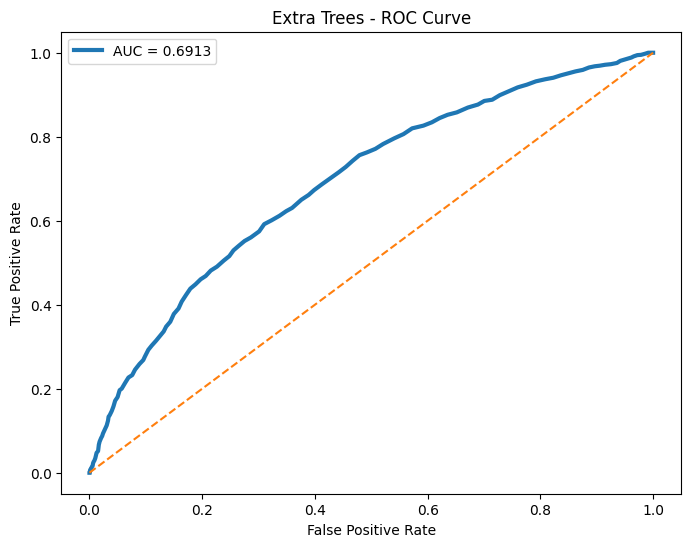



KNN

Accuracy Score: 0.5705
ROC AUC Score: 0.4973

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.70      0.69      3006
           1       0.31      0.30      0.31      1394

    accuracy                           0.57      4400
   macro avg       0.50      0.50      0.50      4400
weighted avg       0.57      0.57      0.57      4400



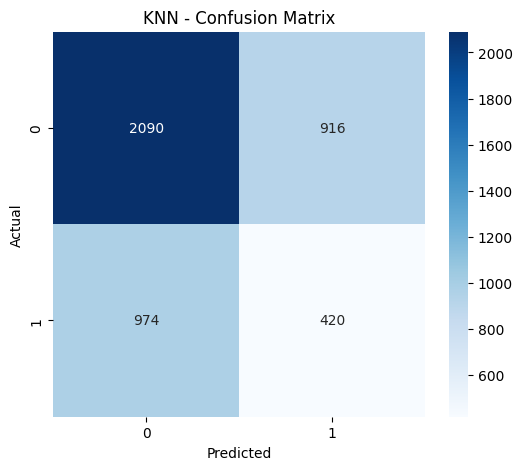

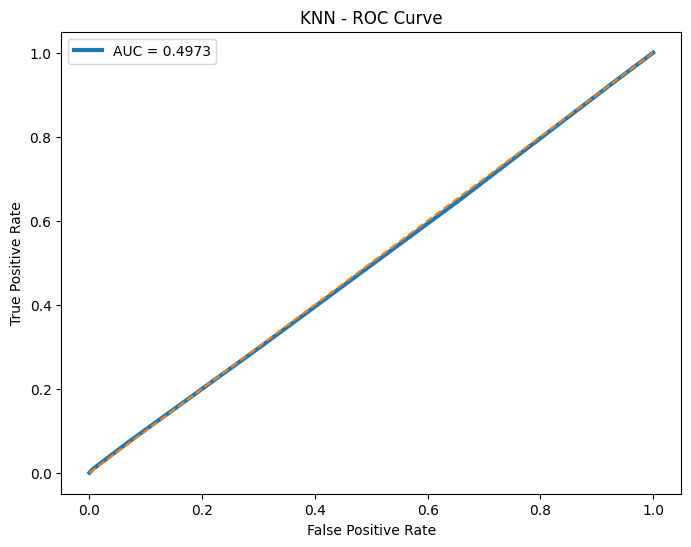



Naive Bayes

Accuracy Score: 0.6275
ROC AUC Score: 0.5483

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.79      0.74      3006
           1       0.38      0.27      0.32      1394

    accuracy                           0.63      4400
   macro avg       0.54      0.53      0.53      4400
weighted avg       0.60      0.63      0.61      4400



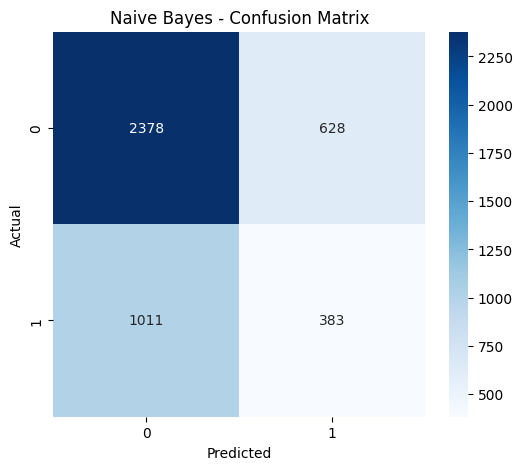

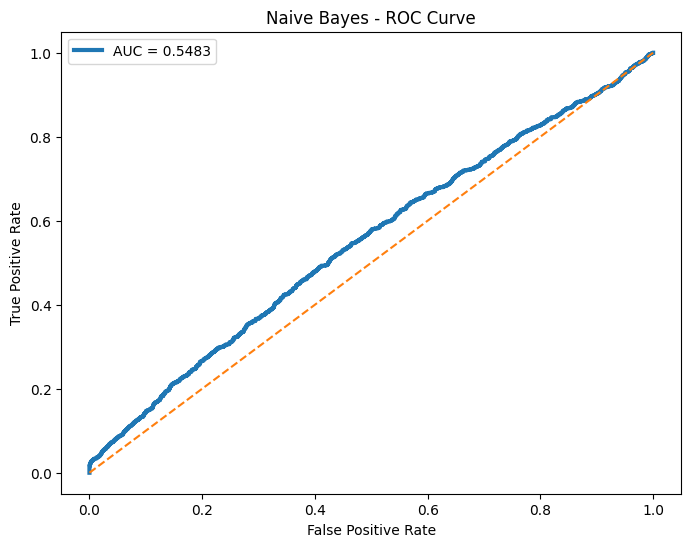



SVM

Accuracy Score: 0.6832
ROC AUC Score: 0.5266

Classification Report:

              precision    recall  f1-score   support

           0       0.68      1.00      0.81      3006
           1       0.50      0.00      0.00      1394

    accuracy                           0.68      4400
   macro avg       0.59      0.50      0.41      4400
weighted avg       0.63      0.68      0.56      4400



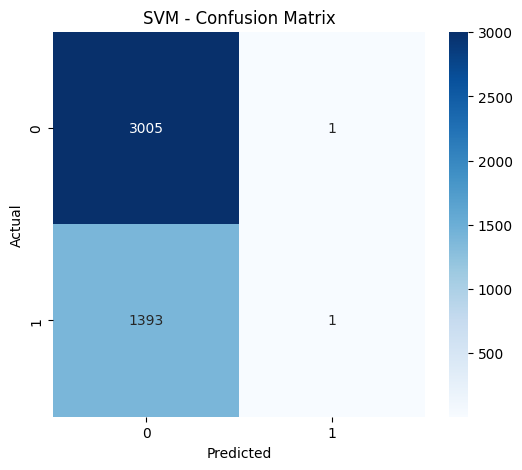

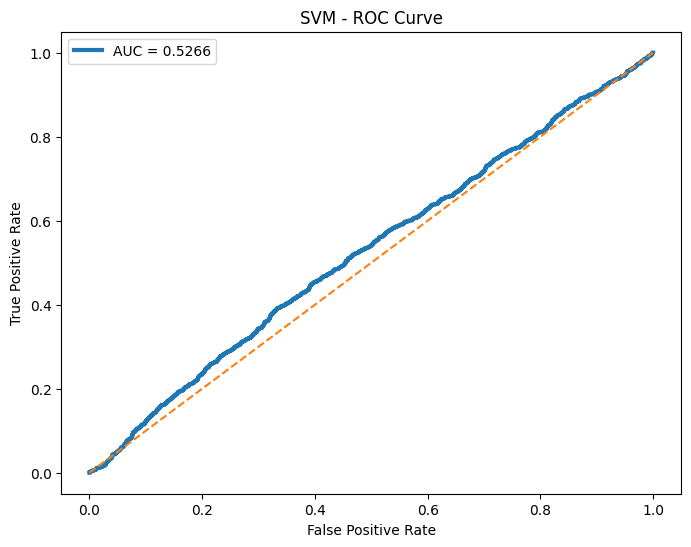



FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
2        Random Forest  0.703182  0.689335
4          Extra Trees  0.702955  0.691340
3    Gradient Boosting  0.687955  0.692437
0  Logistic Regression  0.686136  0.511334
7                  SVM  0.683182  0.526553
1        Decision Tree  0.668409  0.611213
6          Naive Bayes  0.627500  0.548277
5                  KNN  0.570455  0.497335


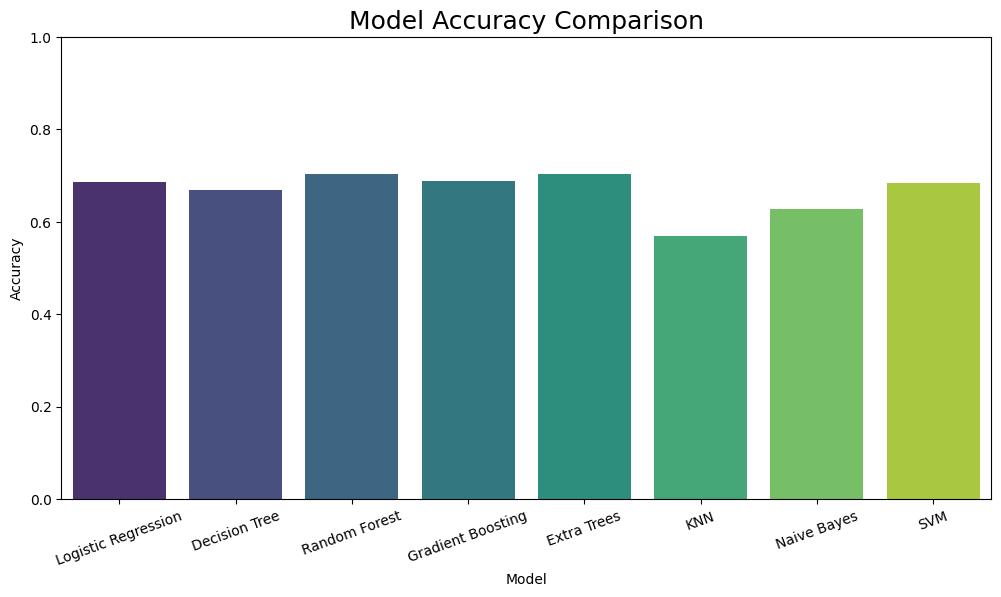

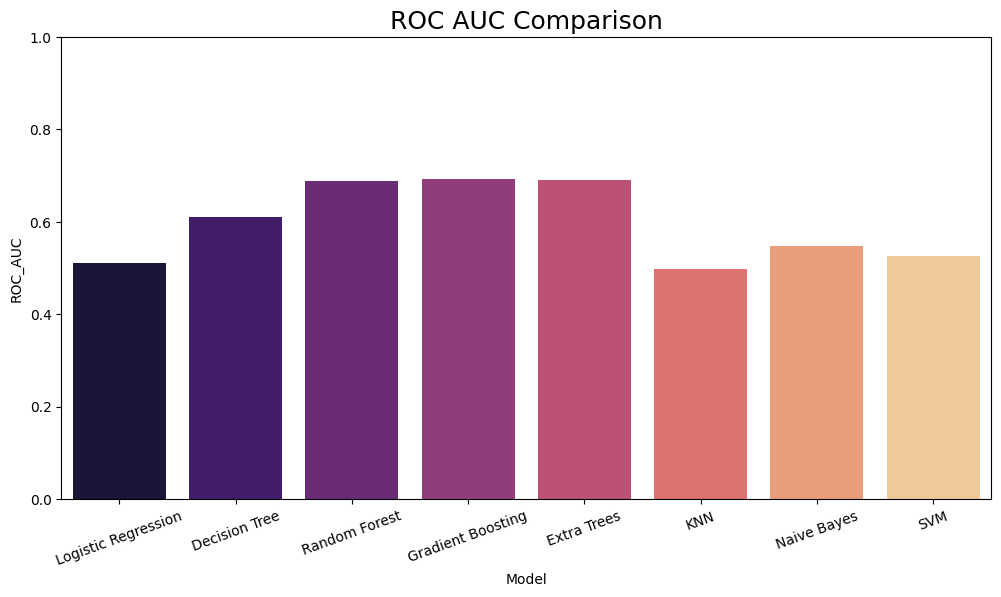

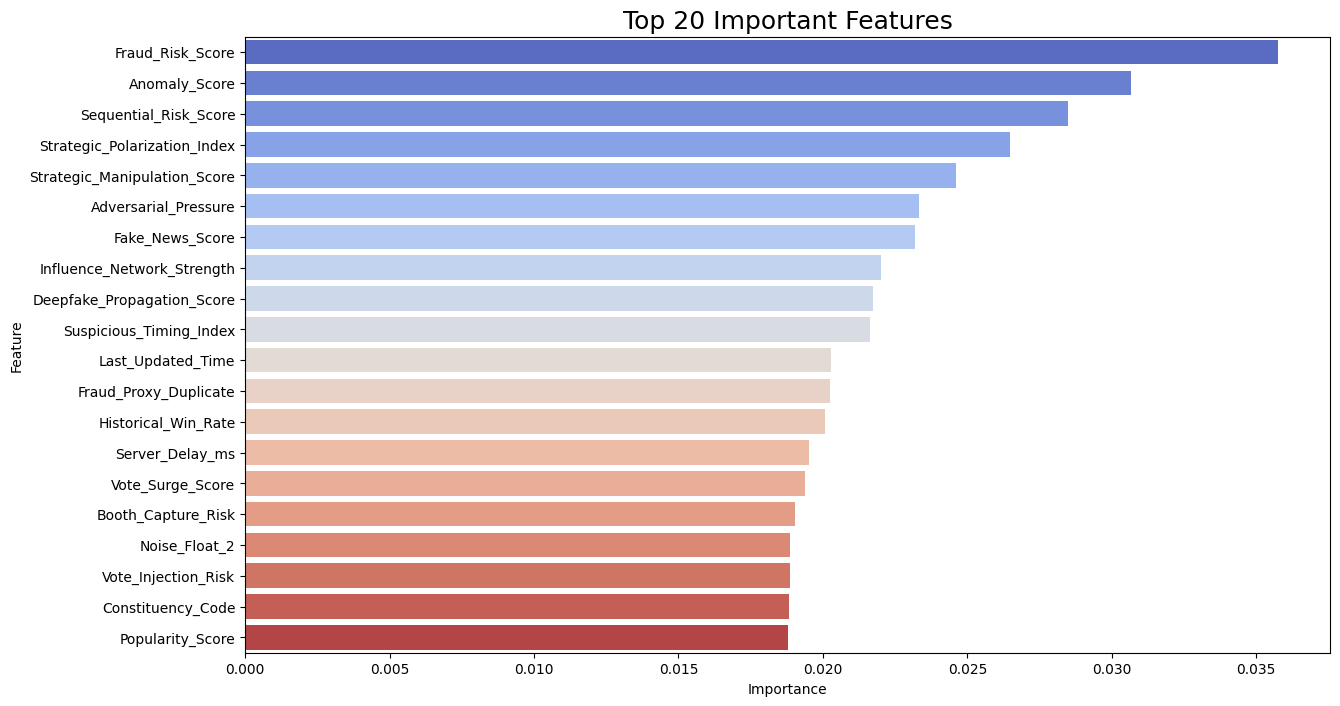



BEST PERFORMING MODEL

Model Name : Random Forest
Accuracy   : 0.7032
ROC AUC    : 0.6893


In [14]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")



# Target Variable
target = "Fraud_Label"

# ============================================================
# DROP LEAKAGE COLUMNS
# ============================================================

# IMPORTANT:
# Removing columns that directly leak information
# about target or future results

leakage_columns = [
    "Fraud_Label",              # Target itself
    "Election_Result",          # Post-election outcome
    "Risk_Category"             # Derived risk category
]

# Remove only if present
leakage_columns = [col for col in leakage_columns if col in df.columns]

X = df.drop(columns=leakage_columns)

y = df[target]

# ============================================================
# LABEL ENCODING TARGET
# ============================================================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print("\nTarget Classes:")
print(target_encoder.classes_)

# ============================================================
# IDENTIFY CATEGORICAL & NUMERICAL COLUMNS
# ============================================================

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

# SPLIT BEFORE ENCODING TO PREVENT DATA LEAKAGE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ============================================================
# HANDLE MISSING VALUES
# ============================================================

# Numerical missing values
num_imputer = SimpleImputer(strategy="median")

# Categorical missing values
cat_imputer = SimpleImputer(strategy="most_frequent")

# ============================================================
# LABEL ENCODING FOR CATEGORICAL FEATURES
# ============================================================

# Manual label encoding WITHOUT leakage

label_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    # Fit ONLY on training data
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

    le.fit(X_train[col])

    X_train[col] = le.transform(X_train[col])

    # Handle unseen labels safely
    X_test[col] = X_test[col].map(
        lambda s: '<unknown>' if s not in le.classes_ else s
    )

    if '<unknown>' in X_test[col].values:
        le_classes = np.append(le.classes_, '<unknown>')
        le.classes_ = le_classes

    X_test[col] = le.transform(X_test[col])

    label_encoders[col] = le

# ============================================================
# HANDLE MISSING VALUES AFTER ENCODING
# ============================================================

X_train[numerical_cols] = num_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = num_imputer.transform(X_test[numerical_cols])

X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=500),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes": GaussianNB(),

    "SVM": SVC(
        probability=True,
        kernel='rbf'
    )
}

# ============================================================
# MODEL TRAINING & EVALUATION
# ============================================================

results = []

print("\n")
print("="*70)
print("MODEL TRAINING & EVALUATION")
print("="*70)

for name, model in models.items():

    print("\n")
    print("="*60)
    print(f"{name}")
    print("="*60)

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    model.fit(X_train, y_train)

    # ========================================================
    # PREDICTIONS
    # ========================================================

    y_pred = model.predict(X_test)

    # ========================================================
    # PROBABILITY PREDICTIONS
    # ========================================================

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(X_test)[:, 1]

    else:

        y_prob = y_pred

    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score: {accuracy:.4f}")

    # ========================================================
    # ROC AUC SCORE
    # ========================================================

    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"ROC AUC Score: {roc_auc:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"{name} - ROC Curve")

    plt.legend()

    plt.show()

    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({

        "Model": name,
        "Accuracy": accuracy,
        "ROC_AUC": roc_auc

    })

# ============================================================
# RESULTS COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

print(results_df.sort_values(by="Accuracy", ascending=False))

# ============================================================
# VISUALIZE MODEL ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df,
    palette="viridis"
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# ============================================================
# VISUALIZE ROC AUC COMPARISON
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x="Model",
    y="ROC_AUC",
    data=results_df,
    palette="magma"
)

plt.title("ROC AUC Comparison", fontsize=18)

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

# Random Forest Feature Importance

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Top 20 Features
top_features = feature_importance.head(20)

plt.figure(figsize=(14,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features,
    palette="coolwarm"
)

plt.title("Top 20 Important Features", fontsize=18)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("\n")
print("="*70)
print("BEST PERFORMING MODEL")
print("="*70)

print(f"\nModel Name : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"ROC AUC    : {best_model['ROC_AUC']:.4f}")